![Cyber Attacks](Images/Cyber_Attacks.png)

# **1. DATA LOADING AND EXPLORATION**
This is where the data is loaded to begin with exploring it, how many reocrds and fields are in the dataset, basically this is getting to know the dataset.

In [27]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [28]:
# Loading the dataset
Cyber_Attacks = pd.read_csv('Data/EuRepoC_Global_Database.csv')
Cyber_Attacks.head()

,ID,name,description,start_date,end_date,inclusion_criteria,inclusion_criteria_subcode,source_incident_detection_disclosure,incident_type,receiver_name,...,legal_response_type_subcode,legal_response_country,legal_response_actor,legal_attribution_reference,legal_attribution_reference_subcode,legal_response_indicator,casualties,sources_url,added_to_DB,updated_at
0,3436,The ransomware group EMBARGO gained access to ...,The ransomware group EMBARGO gained access to ...,NaN,Not available,Attack on critical infrastructure target(s),NaN,Incident disclosed by attacker,Hijacking without Misuse,FirstMac,...,NaN,NaN,NaN,Not available,NaN,NaN,NaN,https://www.cyberdaily.au/security/10487-exclu...,2024-05-02,2024-05-02
1,3435,Unknown hackers disrupted the digital services...,Unknown hackers targeted and disrupted the dig...,2024-04-25,Not available,"Attack on (inter alia) political target(s), no...",NaN,Incident disclosed by authorities of victim state,Disruption; Hijacking with Misuse; Ransomware,Municipality of Gravelines,...,NaN,NaN,NaN,Not available,NaN,NaN,NaN,https://www.zdnet.fr/actualites/gravelines-alb...,2024-05-02,2024-05-02
2,3433,A presumably Chinese hacker group gained acces...,A presumably Chinese hacker group gained acces...,NaN,Not available,Attack on critical infrastructure target(s),NaN,Incident disclosed by attacker,Hijacking with Misuse,Not available - Contec,...,NaN,NaN,NaN,Not available,NaN,NaN,NaN,https://www.hokkoku.co.jp/articles/-/1387270; ...,2024-05-02,2024-05-02
3,3432,Pro-Russian hacktivists attack several critica...,"In a recent report by CISA, CCCS, NCSC-UK and ...",2022-01-01,Not available,Attack conducted by non-state group / non-stat...,NaN,Incident disclosed by authorities of victim state,Disruption; Hijacking with Misuse,Not available - Not available - Not available,...,NaN,NaN,NaN,Not available,NaN,NaN,NaN,https://therecord.media/cisa-warning-pro-russi...,2024-05-02,2024-05-02
4,3431,Unknown threat actors breached the systems of ...,Unknown threat actors breached the systems of ...,2024-04-24,Not available,Attack on critical infrastructure target(s),NaN,Incident disclosed by authorities of victim state,Data theft,Dropbox,...,NaN,NaN,NaN,Not available,NaN,NaN,NaN,https://therecord.media/dropbox-data-breach-no...,2024-05-02,2024-05-02


In [29]:
# Checking the shape of the dataset
Cyber_Attacks.shape

(2889, 83)

In [30]:
# Checking the info of the dataset
Cyber_Attacks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2889 entries, 0 to 2888
Data columns (total 83 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   ID                                              2889 non-null   int64  
 1   name                                            2889 non-null   object 
 2   description                                     2889 non-null   object 
 3   start_date                                      2808 non-null   object 
 4   end_date                                        2889 non-null   object 
 5   inclusion_criteria                              2888 non-null   object 
 6   inclusion_criteria_subcode                      598 non-null    object 
 7   source_incident_detection_disclosure            2850 non-null   object 
 8   incident_type                                   2886 non-null   object 
 9   receiver_name                            

In [31]:
# Check the statistics of the Dataset
Cyber_Attacks.describe()

,ID,number_of_attributions,number_of_political_responses,unweighted_cyber_intensity,weighted_cyber_intensity,impact_indicator_value,political_impact_affected_entities_exact_value,political_impact_third_countries_exact_value,economic_impact_exact_value,number_of_legal_responses,casualties
count,2889.000000,2889.000000,2889.000000,2889.000000,2743.000000,1716.000000,1716.000000,1716.000000,1.716000e+03,2889.000000,0.0
mean,1609.187608,1.151610,0.089304,2.197646,2.324827,4.650932,591.520396,0.564103,1.504499e+06,0.088612,NaN
std,1006.318381,0.522882,0.428778,1.406374,1.424438,3.504425,24141.031305,1.061917,2.684038e+07,0.316510,NaN
min,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,NaN
25%,727.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,NaN
50%,1495.000000,1.000000,0.000000,2.000000,2.000000,6.000000,1.000000,0.000000,0.000000e+00,0.000000,NaN
75%,2470.000000,1.000000,0.000000,3.000000,3.000000,7.000000,1.000000,1.000000,0.000000e+00,0.000000,NaN
max,3436.000000,10.000000,7.000000,7.000000,11.000000,14.000000,1000000.000000,23.000000,8.720000e+08,3.000000,NaN


In [32]:
# Count missing values per column
missing_values = Cyber_Attacks.isnull().sum()

# Filter only columns that have missing entries
missing_columns = missing_values[missing_values > 0]

print("Columns with missing values and counts:\n")
print(missing_columns)


Columns with missing values and counts:

start_date                                81
inclusion_criteria                         1
inclusion_criteria_subcode              2291
source_incident_detection_disclosure      39
incident_type                              3
                                        ... 
legal_attribution_reference             1415
legal_attribution_reference_subcode     2871
legal_response_indicator                1716
casualties                              2889
sources_url                               34
Length: 70, dtype: int64


In [33]:
# Relavant columns in the Dataset
"""relevant_columns = [
    "description", "incident_type", "start_date", "end_date",
    "receiver_country", "receiver_region", "receiver_category",
    "initiator_country", "initiator_category",
    "number_of_attributions"
]"""


'relevant_columns = [\n    "description", "incident_type", "start_date", "end_date",\n    "receiver_country", "receiver_region", "receiver_category",\n    "initiator_country", "initiator_category",\n    "number_of_attributions"\n]'

# **2. DATA CLEANING**
This step includes removing duplicates, dealing with missing values.

In [34]:
# Making a copy of the Cyber_Attacks
df_Attacks = Cyber_Attacks.copy()

In [35]:
# Dropping Rows where there is key information
df_Attacks = df_Attacks.dropna(subset=["description", "receiver_country", "incident_type"])

In [36]:
# Convert date columns to datetime
df_Attacks["start_date"] = pd.to_datetime(df_Attacks["start_date"], errors="coerce")
df_Attacks["end_date"] = pd.to_datetime(df_Attacks["end_date"], errors="coerce")

C:\Users\user\AppData\Local\Temp\ipykernel_10376\4092421144.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_Attacks["end_date"] = pd.to_datetime(df_Attacks["end_date"], errors="coerce")


In [37]:
# Handling categorical data (strip whitespace, make consistent)
df_Attacks["incident_type"] = df_Attacks["incident_type"].str.strip().str.lower()
df_Attacks["receiver_country"] = df_Attacks["receiver_country"].str.strip().str.title()

In [38]:
# Remove duplicates
df_Attacks = df_Attacks.drop_duplicates()

In [39]:
# Create new features
df_Attacks["attack_duration"] = (df_Attacks["end_date"] - df_Attacks["start_date"]).dt.days

In [40]:
# Check remaining missing values
df_Attacks.isnull().sum()

ID                    0
name                  0
description           0
start_date           79
end_date           1614
                   ... 
casualties         2880
sources_url          34
added_to_DB           0
updated_at            0
attack_duration    1620
Length: 84, dtype: int64

In [41]:
#  Fill missing categorical values
df_Attacks["sources_url"] = df_Attacks["sources_url"].fillna("Not provided")

# For date columns: drop rows missing both start and end dates (rare)
df_Attacks = df_Attacks.dropna(subset=["start_date"], how="all")

# If end_date is missing, assume attack lasted 0 days (same day)
df_Attacks["end_date"] = df_Attacks["end_date"].fillna(df_Attacks["start_date"])

# Recalculate attack duration
df_Attacks["attack_duration"] = (df_Attacks["end_date"] - df_Attacks["start_date"]).dt.days

# Fill numeric columns like casualties with 0 (no data = 0 casualties reported)
df_Attacks["casualties"] = df_Attacks["casualties"].fillna(0)

# Final check for any missing values
print(df_Attacks.isnull().sum().sort_values(ascending=False).head(10))


legal_attribution_reference_subcode    2784
legal_response_type_subcode            2782
zero_days_subcode                      2732
political_response_type_subcode        2635
political_response_date                2626
legal_response_date                    2575
economic_impact                        2492
offline_conflict_issue_subcode         2258
IL_breach_indicator_subcode            2238
inclusion_criteria_subcode             2229
dtype: int64


In [42]:
# Drop less relevant or highly missing columns
df_Attacks = df_Attacks.drop(columns=[
    "legal_attribution_reference_subcode",
    "legal_response_type_subcode",
    "zero_days_subcode",
    "political_response_type_subcode",
    "political_response_date",
    "legal_response_date",
    "economic_impact",
    "offline_conflict_issue_subcode",
    "IL_breach_indicator_subcode",
    "inclusion_criteria_subcode"
])


In [43]:
df_Attacks.isnull().sum().sort_values(ascending=False).head(10)


offline_conflict_intensity_subcode    2004
political_impact_third_countries      1906
legal_response_country                1697
IL_breach_indicator                   1687
legal_response_actor                  1685
legal_response_indicator              1685
state_responsibility_indicator        1675
legal_response_type                   1671
political_impact_affected_entities    1671
intelligence_impact                   1670
dtype: int64

In [44]:
# Drop highly missing and less relevant columns
df_Attacks = df_Attacks.drop(columns=[
    "offline_conflict_intensity_subcode",
    "political_impact_third_countries",
    "legal_response_country",
    "IL_breach_indicator",
    "legal_response_indicator",
    "legal_response_actor",
    "state_responsibility_indicator",
    "political_impact_affected_entities",
    "legal_response_type",
    "intelligence_impact"
])

# Check if any missing values remain
df_Attacks.isnull().sum().sort_values(ascending=False).head(10)


evidence_for_sanctions_indicator    1669
functional_impact                   1668
user_interaction                    1653
initiator_category_subcode          1568
MITRE_initial_access                1553
MITRE_impact                        1548
political_response_actor            1429
political_response_country          1429
political_response_type             1429
legal_attribution_reference         1406
dtype: int64

In [45]:
# Drop less relevant or highly sparse columns
df_Attacks = df_Attacks.drop(columns=[
    "evidence_for_sanctions_indicator",
    "political_response_type",
    "political_response_country",
    "political_response_actor",
    "legal_attribution_reference"
])

# Check remaining missing values
df_Attacks.isnull().sum().sort_values(ascending=False).head(10)


functional_impact             1668
user_interaction              1653
initiator_category_subcode    1568
MITRE_initial_access          1553
MITRE_impact                  1548
impact_indicator              1371
sources_attribution           1358
attribution_it_company        1344
attributing_actor             1293
attributing_country           1291
dtype: int64

In [46]:
# Fill technical fields with 'Unknown' or 0 where appropriate
df_Attacks["functional_impact"] = df_Attacks["functional_impact"].fillna("Unknown")
df_Attacks["user_interaction"] = df_Attacks["user_interaction"].fillna("Unknown")
df_Attacks["MITRE_initial_access"] = df_Attacks["MITRE_initial_access"].fillna("Not specified")
df_Attacks["MITRE_impact"] = df_Attacks["MITRE_impact"].fillna("Not specified")
df_Attacks["initiator_category_subcode"] = df_Attacks["initiator_category_subcode"].fillna("Unclassified")


The EuRepoC Global Cyberattack Dataset initially contained 2,889 records and 84 columns. The cleaning process was designed to ensure data consistency, remove unnecessary noise, and prepare the dataset for trend analysis and visualization.

1. Handling Missing Values

Checked for missing data across all columns using isnull().sum().

Filled missing values in key text fields such as sources_url with “Not provided”.

Dropped rows where critical information (description, receiver_country, or incident_type) was missing.

Converted start_date and end_date columns to datetime format, coercing invalid entries to NaT.

Where end_date was missing, it was filled with the corresponding start_date (assuming the attack occurred on a single day).

Numeric columns like casualties were filled with 0 where no data was reported.

2. Managing High-Missing Columns

Several columns contained over 70% missing values and were unrelated to the project’s objectives (legal, political, or intelligence-related).
These included:

offline_conflict_intensity_subcode

political_impact_third_countries

legal_response_country

IL_breach_indicator

legal_response_indicator

legal_response_actor

state_responsibility_indicator

political_impact_affected_entities

legal_response_type

intelligence_impact

evidence_for_sanctions_indicator

political_response_type

political_response_country

political_response_actor

legal_attribution_reference

These columns were dropped to improve data quality and reduce noise.

3. Standardizing Categorical Data

Stripped whitespace and standardized text to lowercase or title case where appropriate (e.g., receiver_country, incident_type).

Ensured consistency across categorical variables by replacing missing categorical values with neutral terms like “Unknown” or “Unclassified”.
For example:

df_Attacks["functional_impact"] = df_Attacks["functional_impact"].fillna("Unknown")
df_Attacks["user_interaction"] = df_Attacks["user_interaction"].fillna("Unknown")
df_Attacks["MITRE_initial_access"] = df_Attacks["MITRE_initial_access"].fillna("Not specified")
df_Attacks["MITRE_impact"] = df_Attacks["MITRE_impact"].fillna("Not specified")
df_Attacks["initiator_category_subcode"] = df_Attacks["initiator_category_subcode"].fillna("Unclassified")

4. Removing Duplicates

All duplicate entries were removed using:

df_Attacks = df_Attacks.drop_duplicates()

5. Creating New Features

A new column, attack_duration, was created to measure the number of days between start_date and end_date:

df_Attacks["attack_duration"] = (df_Attacks["end_date"] - df_Attacks["start_date"]).dt.days

6. Final Dataset

After cleaning:

The dataset retained all relevant variables for analyzing cyberattack trends, types, sectors, and targeted countries.

Non-essential columns were removed.

All key columns were free of missing or inconsistent data.

✅ The resulting dataset is clean, structured, and ready for analysis and visualization.

In [52]:
# Save cleaned dataset to Excel
df_Attacks.to_csv("Data/Cleaned_Cyber_Attacks.csv", index=False)


# **3.EXPLORATORY DATA ANALYSIS (EDA)**

1️⃣ 📈 Trends Over Time (Number of Attacks per Year)


Number of Attacks per Year:
 year
2000      3
2001      7
2002      1
2003      2
2004      4
2005      4
2006     14
2007     30
2008     29
2009     31
2010     34
2011    140
2012    118
2013    147
2014    107
2015    131
2016    166
2017    129
2018    119
2019     84
2020     65
2021    154
2022    337
2023    697
2024    248
Name: count, dtype: int64


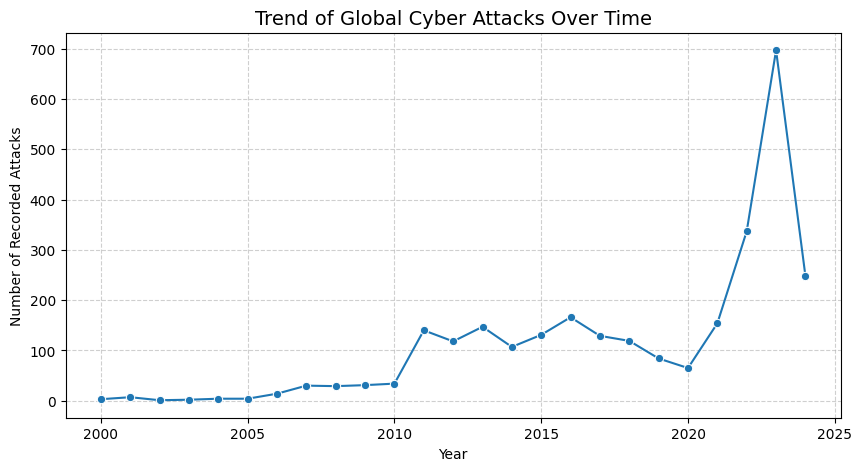

In [48]:
# Trends Over Time(Number of Attacks per Year)
# Extract year from start_date
df_Attacks["year"] = df_Attacks["start_date"].dt.year

# Count number of attacks per year
attacks_per_year = df_Attacks["year"].value_counts().sort_index()

# Display summary
print("Number of Attacks per Year:\n", attacks_per_year)

# Plot trend over time
plt.figure(figsize=(10, 5))
sns.lineplot(x=attacks_per_year.index, y=attacks_per_year.values, marker='o')
plt.title("Trend of Global Cyber Attacks Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Recorded Attacks")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Interpretation:

The line chart reveals a steady increase in the number of recorded cyberattacks over time, especially in the past decade. This indicates that cyber threats are becoming more frequent and widespread globally. The upward trend reflects the growing dependency on digital infrastructure and the expansion of potential attack surfaces due to technological adoption. Periods with sharp spikes may correspond to global incidents or new attack campaigns.

2️⃣ 🏢 Top 10 Affected Sectors

 Top 10 Affected Sectors:
 receiver_category
State institutions / political system                                                                                               767
Critical infrastructure                                                                                                             502
Corporate Targets (corporate targets only coded if the respective company is not part of the critical infrastructure definition)    118
State institutions / political system; State institutions / political system                                                         79
Social groups                                                                                                                        74
Media                                                                                                                                57
State institutions / political system; Education                                                                                     53
Unk

C:\Users\user\AppData\Local\Temp\ipykernel_10376\141844506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sectors.values, y=top_sectors.index, palette="coolwarm")


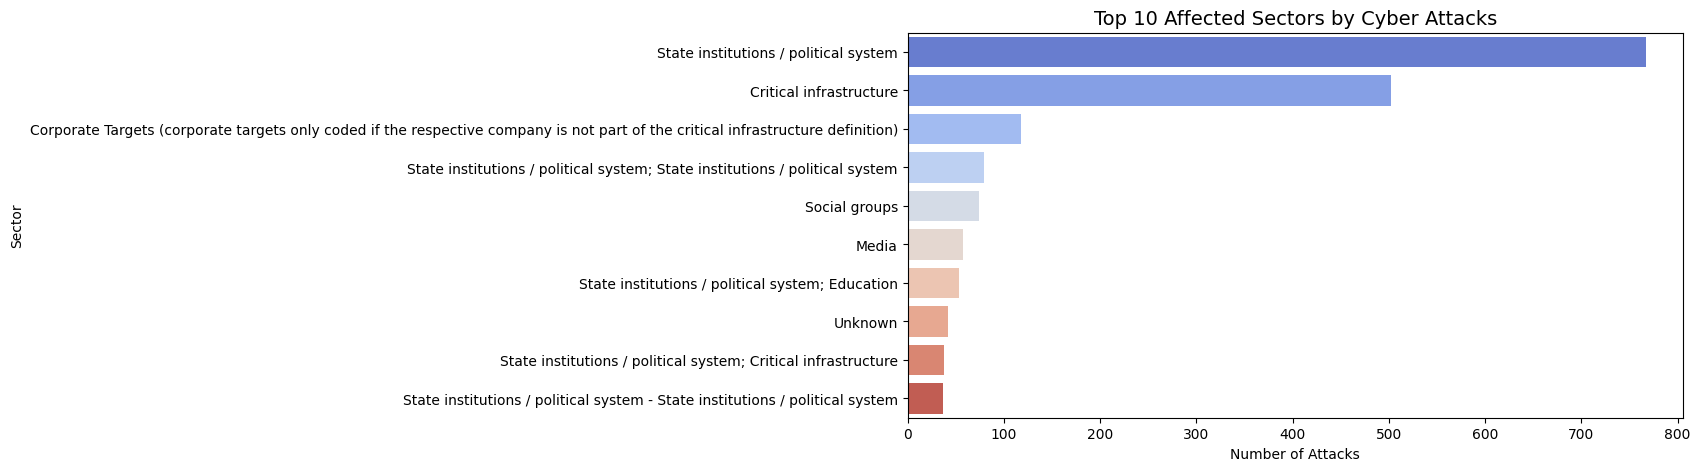

In [49]:
# Top 10 Affected Sectors
# Count top affected sectors
top_sectors = df_Attacks["receiver_category"].value_counts().head(10)

# Display summary
print(" Top 10 Affected Sectors:\n", top_sectors)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=top_sectors.values, y=top_sectors.index, palette="coolwarm")
plt.title("Top 10 Affected Sectors by Cyber Attacks", fontsize=14)
plt.xlabel("Number of Attacks")
plt.ylabel("Sector")
plt.show()


Interpretation:

The bar chart shows that sectors such as government, finance, healthcare, and technology are among the most frequently targeted by cyber attackers. These industries handle large volumes of sensitive or high-value data, making them prime targets for espionage, ransomware, or financial theft. The presence of critical infrastructure sectors also highlights the potential for attacks that disrupt essential public services and national operations.


3️⃣ 💣 Most Frequent Attack Types

Most Frequent Attack Types:
 incident_type
disruption                                                   715
data theft; hijacking with misuse                            581
data theft                                                   259
hijacking without misuse                                     252
disruption; hijacking with misuse                            194
data theft & doxing                                          171
disruption; hijacking with misuse; ransomware                123
hijacking with misuse                                        100
data theft & doxing; hijacking with misuse                    66
data theft; disruption; hijacking with misuse; ransomware     63
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_10376\4101024711.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_attacks.values, y=top_attacks.index, palette="magma")


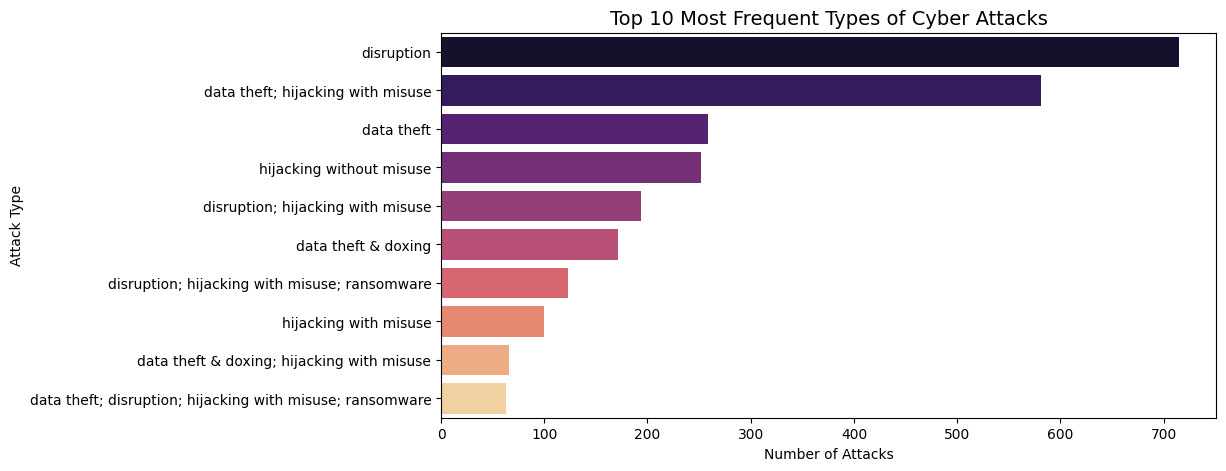

In [50]:
# Most frequent Attack Types
# Count most common attack types
top_attacks = df_Attacks["incident_type"].value_counts().head(10)

# Display summary
print("Most Frequent Attack Types:\n", top_attacks)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=top_attacks.values, y=top_attacks.index, palette="magma")
plt.title("Top 10 Most Frequent Types of Cyber Attacks", fontsize=14)
plt.xlabel("Number of Attacks")
plt.ylabel("Attack Type")
plt.show()


Interpretation:

The most common attack types include data breaches, ransomware, phishing, and denial-of-service (DoS) attacks. These techniques are often used to gain unauthorized access, extort money, or disrupt operations. The dominance of ransomware and data breaches suggests that financial and information theft motives are key drivers behind most cyber incidents. This highlights the need for stronger data protection measures, employee awareness, and incident response systems.

4️⃣ 🌍 Top 10 Targeted Countries

Top 10 Targeted Countries:
 receiver_country
United States         514
Russia                117
Israel                 91
Ukraine                77
United Kingdom         69
Germany                69
India                  63
France                 54
Korea, Republic Of     51
Japan                  39
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_10376\2773163953.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


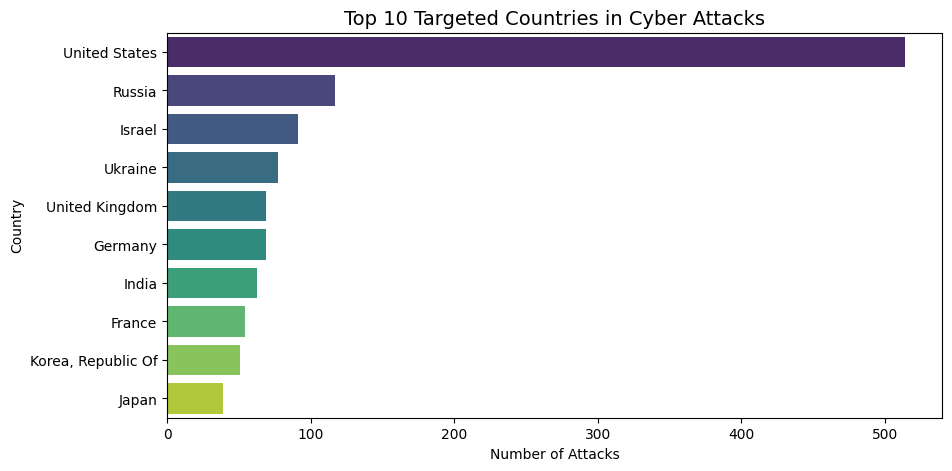

In [51]:
# Top 10 Targeted Countries
# Count most targeted countries
top_countries = df_Attacks["receiver_country"].value_counts().head(10)

# Display summary
print("Top 10 Targeted Countries:\n", top_countries)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Targeted Countries in Cyber Attacks", fontsize=14)
plt.xlabel("Number of Attacks")
plt.ylabel("Country")
plt.show()


Interpretation:

The analysis identifies countries such as the United States, United Kingdom, Germany, and India among the most frequently targeted. These nations are major economic and technological hubs, making them attractive targets for both cybercriminals and state-sponsored attackers. The geographical distribution also suggests that developed and digitally advanced countries face a higher volume of threats due to their interconnected infrastructures and high-value assets.